In [75]:
import os
import pandas as pd
from ultralytics import YOLO
import cv2
from datetime import datetime

In [76]:
model = YOLO('runs/train/product_model/weights/best.pt')

In [77]:
def create_image_dataframe(folder_path, labels_path):
    # image files and paths
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg'))]
    full_image_paths = [os.path.join(folder_path, f) for f in image_files]
    label_files = [os.path.join(labels_path, f.replace('.jpeg', '.txt')) for f in image_files]

    # create dataframe
    df = pd.DataFrame({
        'image_name': image_files,
        'image_path': full_image_paths,
        'label_path': label_files
    })
    
    return df

# create dataframe for the test (holdout) set
image_folder = 'images/val'
label_folder = 'labels/val'
test_df = create_image_dataframe(image_folder, label_folder)
test_df.head(2)

,image_name,image_path,label_path
0,quarter_10.jpeg,images/val/quarter_10.jpeg,labels/val/quarter_10.txt
1,IMG_4986.jpeg,images/val/IMG_4986.jpeg,labels/val/IMG_4986.txt


In [78]:
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [79]:
file_paths = test_df['image_path'].tolist()

In [80]:
results = model.predict(source=file_paths, conf=0.1, save = True, save_txt = True, name=f'product_predict0_{current_time}')


0: 640x640 1 quarter, 1 product, 85.0ms
1: 640x640 1 quarter, 5 products, 85.0ms
2: 640x640 2 quarters, 2 products, 85.0ms
3: 640x640 1 quarter, 85.0ms
4: 640x640 1 quarter, 1 product, 85.0ms
5: 640x640 1 quarter, 1 product, 85.0ms
6: 640x640 1 quarter, 1 product, 85.0ms
7: 640x640 1 quarter, 1 product, 85.0ms
Speed: 6.6ms preprocess, 85.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/runs/detect/product_predict0_2025-04-12_04-12-15
8 labels saved to /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/runs/detect/product_predict0_2025-04-12_04-12-15/labels


In [81]:
results = model('images/val/IMG_4986.jpeg')
print(results[0].boxes)  # Check if any boxes exist at all



image 1/1 /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/images/val/IMG_4986.jpeg: 640x480 1 quarter, 1 product, 81.8ms
Speed: 8.5ms preprocess, 81.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/runs/detect/product_predict0_2025-04-12_04-12-15
8 labels saved to /Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/runs/detect/product_predict0_2025-04-12_04-12-15/labels
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0.])
conf: tensor([0.9068, 0.6028])
data: tensor([[1.2584e+03, 4.3552e+02, 2.0879e+03, 3.7400e+03, 9.0682e-01, 1.0000e+00],
        [8.3810e+02, 3.0293e+03, 1.1800e+03, 3.3829e+03, 6.0280e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (4032, 3024)
shape: torch.Size([2, 6])
xywh: tensor([[1673.1558, 2087.7822,  829.5708, 3304.5212],
        [1009.0684, 32

In [82]:
from segment_anything import (
    sam_model_registry,
    SamAutomaticMaskGenerator,
    SamPredictor,
)
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [83]:
# initialize list to store all the masks
product_masks = []

[ WARN:0@121597.519] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


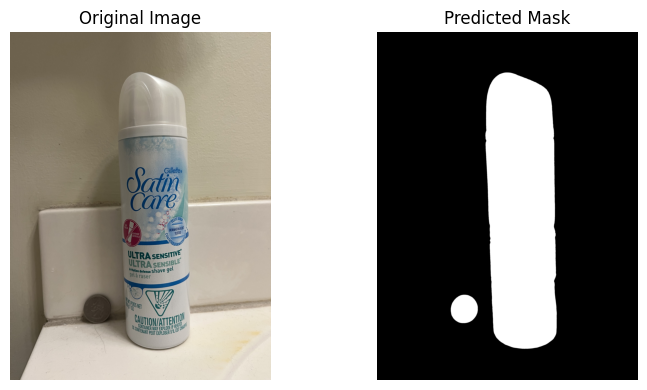

In [84]:
for result in results:

    # get predicted boxes
    boxes = result.boxes.xyxy

    # read in the original image
    image_path = result.path
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

    # load the SAM model
    HOME = os.getcwd()
    CHECKPOINT_PATH = os.path.join(HOME, "sam_vit_h_4b8939.pth")
    DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    MODEL_TYPE = "vit_h"
    sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)
    mask_predictor = SamPredictor(sam)

    # transform the YOLOv8 predicted boxes to match input format expected by SAM model
    transformed_boxes = mask_predictor.transform.apply_boxes_torch(boxes, image_bgr.shape[:2])

    # run SAM model on all the boxes
    mask_predictor.set_image(image_bgr)
    masks, scores, logits = mask_predictor.predict_torch(
       boxes=transformed_boxes,
       multimask_output=False,
       point_coords=None,
       point_labels=None
    )

    # initialize an empty mask with the same size as the original image
    final_mask = np.zeros_like(image_bgr[:,:,0], dtype=np.uint8)

    # combine all masks into one
    for mask in masks:
        final_mask += mask[0].cpu().numpy().astype(np.uint8)

    # normalize the final mask
    final_mask = (final_mask - np.min(final_mask)) / (np.max(final_mask) - np.min(final_mask)) * 255

    # append the final mask
    product_masks.append(final_mask)

    # save the mask to a file (for visualization or further use)
    mask_filename = os.path.join("/Users/andreanoh/Documents/Spring 2025 6010 ComputerVision/cv_product_info_extract/runs/detect/segment", f"mask_{os.path.basename(image_path)}.png")
    cv2.imwrite(mask_filename, final_mask)

    # set colors for mask visual
    final_mask_color = np.zeros_like(image_bgr)
    final_mask_color[final_mask != 0] = [255, 255, 255]
    final_mask_color[final_mask == 0] = [0, 0, 0]

    # figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

    # first subplot: Original Image
    axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')  # Hide axes

    # second subplot: Predicted Mask
    axes[1].imshow(cv2.cvtColor(final_mask_color, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Predicted Mask')
    axes[1].axis('off')  # Hide axes

    plt.tight_layout()
    plt.show()